In [1]:
import os

print(os.getcwd())

C:\Users\DELL\OneDrive\Desktop\Psyliq_Project


In [2]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("psyliq_scam.db")

# Load Government Actions data from Excel
df = pd.read_excel("Data_Matrix_P1.xlsx", sheet_name="04_Government_Actions")

# Create SQL table
df.to_sql("government_actions", conn, if_exists="replace", index=False)

# Query: average estimated funds recovered by agency
query = """
SELECT
    Agency,
    COUNT(*) AS Action_Count,
    AVG(Est_Funds_Recovered_USD) AS Avg_Funds_Recovered
FROM government_actions
GROUP BY Agency
ORDER BY Avg_Funds_Recovered DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Agency,Action_Count,Avg_Funds_Recovered
0,DOJ / U.S. Attorney's Office,10,3565318.608


In [3]:
import os

print(os.getcwd())

C:\Users\DELL\OneDrive\Desktop\Psyliq_Project


In [4]:
import os

print(os.listdir())


['.ipynb_checkpoints', 'Data_Matrix_P1.xlsx', 'Psyliq_P1_Scam_Profiling.ipynb', 'psyliq_scam.db']


In [5]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Data_Matrix_P1.xlsx', 'Psyliq_P1_Scam_Profiling.ipynb', 'psyliq_scam.db']


In [6]:
import pandas as pd

df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="04_Government_Actions"
)

df.head()

,Action_ID,Agency,Targeted_Scam_Type,Date_of_Action,Est_Funds_Recovered_USD,Action,Description,Source,Source_URL
0,A001,DOJ / U.S. Attorney's Office,Tech Support / Government Impersonation,44165,8970396.00,Sentencing and restitution,India-based call-center operator sentenced; co...,DOJ,https://www.justice.gov/usao-sdtx/pr/owner-and...
1,A002,DOJ / U.S. Attorney's Office,Romance Scam / Money Laundering,44266,325100.00,Sentencing and restitution,Nigerian national sentenced for money-launderi...,DOJ,https://www.justice.gov/usao-md/pr/nigerian-na...
2,A003,DOJ / U.S. Attorney's Office,Romance Scam / Money Laundering,44449,500740.00,Sentencing and restitution,Manager of Nigerian romance-scam money-launder...,DOJ,https://www.justice.gov/usao-ndok/pr/us-manage...
3,A004,DOJ / U.S. Attorney's Office,Business Email Compromise / Romance Fraud,44384,865210.78,Sentencing and restitution,Defendant sentenced for laundering proceeds fr...,DOJ,https://www.justice.gov/usao-wdtx/pr/nigerian-...
4,A005,DOJ / U.S. Attorney's Office,Romance Scam / Money Laundering,44637,2307020.00,Sentencing and restitution,Georgia man sentenced for laundering approxima...,DOJ,https://www.justice.gov/usao-ednc/pr/georgia-m...


In [7]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("psyliq_scam.db")

# Excel data को SQLite table में डालना
df.to_sql(
    "government_actions",
    conn,
    if_exists="replace",
    index=False
)

print("Government Actions table created successfully!")

Government Actions table created successfully!


In [8]:
query = """
SELECT
    Agency,
    COUNT(*) AS Action_Count,
    AVG(Est_Funds_Recovered_USD) AS Avg_Funds_Recovered
FROM government_actions
GROUP BY Agency
ORDER BY Avg_Funds_Recovered DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Agency,Action_Count,Avg_Funds_Recovered
0,DOJ / U.S. Attorney's Office,10,3565318.608


# Project 1: Scam Execution & Victim Profiling

## 1. Project Overview

### Objective
Analyze U.S. cybercrime victim demographics, geographical hotspots, scammer tactics, and government countermeasures to identify actionable opportunities for scam prevention and intervention.

### Research Period
2020-2024

### Primary Sources
- FBI Internet Crime Complaint Center (IC3)
- Federal Trade Commission (FTC)
- U.S. Department of Justice (DOJ)
- FBI Public Service Announcements

## 1.3 Government Response & Future Defense

### Objective
Evaluate major U.S. government anti-scam actions between 2020 and 2024 and identify opportunities for future scam prevention.

### Analysis Question
Which government agency has the highest average estimated funds recovered per action?

In [ ]:
# Display government action analysis result

result

### Finding

The analyzed government actions were all associated with the DOJ / U.S. Attorney's Office. Across the 10 actions, the average estimated funds recovered per action was approximately $3.57 million.

### Limitation

Because the compiled sample contains DOJ-related actions only, the analysis does not provide a cross-agency comparison. Therefore, DOJ has the highest average within this dataset, but this should not be interpreted as evidence that DOJ has the highest recovery average among all U.S. government agencies.

## 1.1 Victim Demographics & Geographical Hotspots

### Objective
Quantify and visualize the distribution of cybercrime complaints across age groups and U.S. states from 2020 to 2024.

### Key Questions
1. How has complaint volume changed across different age groups?
2. Which age group shows the strongest growth?
3. Which U.S. states had the highest complaint volume in 2024?
4. What unexpected demographic or geographic trend can be observed since 2020?

In [ ]:
import pandas as pd

excel_file = "Data_Matrix_P1.xlsx"

sheets = pd.ExcelFile(excel_file).sheet_names

print(sheets)

In [ ]:
age_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="01_Age_Data"
)

age_df.head()

In [ ]:
age_df.info()

In [ ]:
age_df

In [ ]:
import matplotlib.pyplot as plt

# Age-group data ko alag karna
age_20_29 = age_df[age_df["Age_Group"] == "20-29"]
age_60_plus = age_df[age_df["Age_Group"] == "60+"]

# Chart banana
plt.figure(figsize=(10, 6))

plt.plot(
    age_20_29["Year"],
    age_20_29["Complaint_Count"],
    marker="o",
    label="Age 20-29"
)

plt.plot(
    age_60_plus["Year"],
    age_60_plus["Complaint_Count"],
    marker="o",
    label="Age 60+"
)

plt.title("Complaint Volume by Age Group (2020-2024)")
plt.xlabel("Year")
plt.ylabel("Complaint / Victim Count")
plt.xticks(age_df["Year"].unique())
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
state_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="02_State_Data"
)

state_df.head()

In [ ]:
# Sirf original state-level data columns rakho
state_clean = state_df[
    ["Year", "Source", "State", "Complaint_Count",
     "Unit", "Source_Report", "Page/Table", "Source_URL"]
].copy()

# 2024 data filter karo
state_2024 = state_clean[state_clean["Year"] == 2024].copy()

# Complaint volume ke according descending sort
top10_states = (
    state_2024
    .sort_values("Complaint_Count", ascending=False)
    .head(10)
)

top10_states[["State", "Complaint_Count"]]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top10_states["State"],
    top10_states["Complaint_Count"]
)

plt.title("Top 10 U.S. States by Scam Complaint Volume - 2024")
plt.xlabel("Number of Complaints")
plt.ylabel("State")

# Highest complaints ko top par dikhana
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# 2020 aur 2024 ke age-group values
age_2020 = age_df[age_df["Year"] == 2020].set_index("Age_Group")["Complaint_Count"]
age_2024 = age_df[age_df["Year"] == 2024].set_index("Age_Group")["Complaint_Count"]

# Percentage growth
growth = ((age_2024 - age_2020) / age_2020) * 100

growth.sort_values(ascending=False)

### Observation

The 60+ age group showed the strongest growth in reported cybercrime victim/complaint volume between 2020 and 2024. The reported count increased by approximately 39.7%, compared with only 0.9% growth for the 20-29 age group.

This is an important finding because the older population is not only experiencing higher complaint volumes but is also showing substantially faster growth over the period analyzed. This suggests that older adults should be treated as a priority demographic for targeted scam-awareness and real-time intervention strategies.

In [ ]:
narrative_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="03_Scam_Narratives"
)

narrative_df.head()

In [ ]:
# Column names ko clean format mein dekhna
print(narrative_df.columns.tolist())

In [ ]:
# Top 5 most frequent urgency keywords

top5_urgency = (
    narrative_df["Urgency_Keyword"]
    .value_counts()
    .head(5)
)

top5_urgency

In [ ]:
# Top 3 payment methods demanded by scammers

payment_counts = (
    narrative_df["Payment_Method"]
    .str.split(" / ")
    .explode()
    .str.strip()
    .value_counts()
    .head(3)
)

payment_counts

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    payment_counts.index,
    payment_counts.values
)

plt.title("Top 3 Payment Methods Demanded by Scammers")
plt.xlabel("Payment Method")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# Platform frequency

platform_counts = (
    narrative_df["Platform"]
    .value_counts()
)

platform_counts

In [ ]:
# Split combined platform values and count individual platforms

platform_counts = (
    narrative_df["Platform"]
    .str.split(" / ")
    .explode()
    .str.strip()
    .value_counts()
)

platform_counts

In [ ]:
import matplotlib.pyplot as plt

# Top platforms
top_platforms = platform_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_platforms.index[::-1],
    top_platforms.values[::-1]
)

plt.title("Top Platforms Used in Scam Narratives")
plt.xlabel("Frequency")
plt.ylabel("Platform")

plt.tight_layout()
plt.show()

## 1.2 Scammer Tactics & Intervention Analysis

### Common Imposter Scam Script

Based on the collected scam narratives, a common imposter-fraud pattern follows these stages:

1. **Initial Contact** – The scammer contacts the victim through phone calls, text messages, email, social media, or other online platforms.

2. **Impersonation & Problem Creation** – The scammer claims to represent a trusted organization, company, government agency, technical-support team, or another person.

3. **Urgency or Fear** – The victim is told that immediate action is required. Common urgency terms in the dataset include "immediately," "now," "urgent," "emergency," and "soon."

4. **Specific Demand** – The scammer instructs the victim to provide information, purchase a payment method, transfer money, or send cryptocurrency.

5. **Payment / Victim Action** – The victim is pressured to follow the instructions, often while being discouraged from seeking outside help.

6. **Intervention Opportunity** – The strongest opportunity for prevention is before the victim provides credentials or completes the requested payment.

In [ ]:
# Compare payment methods for 2023 and 2024

payment_year = (
    narrative_df[narrative_df["Year"].isin([2023, 2024])]
    .assign(Payment_Method=narrative_df[narrative_df["Year"].isin([2023, 2024])]["Payment_Method"].str.split(" / "))
    .explode("Payment_Method")
)

payment_year["Payment_Method"] = payment_year["Payment_Method"].str.strip()

payment_shift = pd.crosstab(
    payment_year["Year"],
    payment_year["Payment_Method"]
)

payment_shift

### Observation: Shift in Payment Methods

Between 2023 and 2024, cryptocurrency remained consistently prominent in the collected scam narratives, with 3 mentions in both years. However, the dataset shows a shift away from gift cards, which declined from 3 mentions in 2023 to 2 in 2024. At the same time, cash and precious metals appeared as new payment-related methods in 2024, with 2 mentions each.

This suggests that scammers may be diversifying their payment and monetization channels rather than relying on a single method. The appearance of cash and precious metals indicates that scam operations can adapt their demands to different victim profiles and circumstances.

Because this analysis is based on a small narrative sample rather than a population-level dataset, the finding should be treated as an indicative trend rather than a definitive industry-wide shift.

# Executive Summary

This project analyzes U.S. scam activity from 2020 to 2024 using victim demographics, geographical complaint patterns, scammer tactics, payment methods, and government enforcement actions.

The analysis identifies older adults (60+) as the fastest-growing vulnerable demographic among the two selected age groups, with reported victim/complaint volume increasing by approximately 39.7% between 2020 and 2024.

In the 2024 state-level analysis, California recorded the highest scam complaint volume among the states included in the dataset, followed by Texas and Florida.

The scam narrative analysis found "immediately" to be the most frequent urgency keyword. Cryptocurrency was the most frequently observed payment method in the collected narratives.

Government-response analysis of the compiled actions showed an average estimated recovery of approximately $3.57 million per DOJ-related action. However, the dataset contained DOJ-related actions only, so cross-agency comparison is limited.

Overall, the findings indicate an opportunity for proactive, real-time scam intervention using AI/ML-based detection, behavioral signals, and payment-risk monitoring.

## Methodology

### Data Sources

The analysis uses publicly available U.S. government sources, including:

- FBI Internet Crime Complaint Center (IC3) Annual Reports
- Federal Trade Commission (FTC) Consumer Sentinel Network data
- FBI Public Service Announcements and victim-awareness materials
- U.S. Department of Justice (DOJ) press releases and enforcement actions

### Data Preparation

The collected information was structured in Excel and imported into Python using Pandas.

The analysis included:

- Age-group comparison for 2020–2024
- State-level complaint analysis for 2024
- Scam narrative and urgency-keyword analysis
- Payment-method frequency analysis
- Platform prevalence analysis
- Government anti-scam action analysis using SQLite and SQL

### Analytical Techniques

The project used:

- Descriptive statistics
- Percentage growth analysis
- Frequency analysis
- Data filtering and sorting
- Text splitting and keyword counting
- Data visualization
- SQL aggregation using GROUP BY and AVG

### Important Data Limitation

The age dataset uses "Victims" as the reporting unit for 2020–2022 and "Complaints" for 2023–2024. Therefore, comparisons across the entire period should be interpreted as reported victim/complaint trends rather than a perfectly consistent complaint series.

The scam-narrative analysis is based on a limited collected sample and should be interpreted as an indicative pattern rather than a population-level estimate.

## Key Findings

### 1. Victim Demographics
- The 60+ age group showed approximately 39.7% growth in reported victim/complaint volume from 2020 to 2024.
- The 20–29 age group showed only approximately 0.9% growth over the same period.
- This indicates that older adults should be considered a priority demographic for scam-prevention interventions.

### 2. Geographical Hotspots
- California recorded the highest 2024 scam complaint volume in the analyzed state dataset.
- Texas and Florida followed California.
- The Top 10 states provide a useful starting point for geographically targeted awareness and intervention strategies.

### 3. Scammer Tactics
- "Immediately" was the most frequent urgency keyword in the collected scam narratives.
- Phone was the most frequently observed individual platform.
- Scammers commonly combine impersonation, urgency, fear, and specific payment instructions to influence victim behavior.

### 4. Payment Methods
- Cryptocurrency was the most frequently observed payment method in the collected narratives.
- Wire transfers and gift cards were the next most frequent methods.
- The 2023–2024 comparison suggests that scammers are diversifying payment demands, including cash and precious metals.

### 5. Government Response
- The analyzed government-action dataset contained 10 DOJ-related actions.
- The average estimated funds recovered per action was approximately $3.57 million.
- A key limitation is that the dataset does not contain enough agency diversity for a true cross-agency comparison.

## Recommendations

### 1. Real-Time AI Scam Detection
Psyliq can develop an AI/ML-based detection system that identifies scam indicators such as urgency, threats, impersonation language, suspicious links, and unusual communication patterns in real time.

### 2. Risk-Based Payment Intervention
Psyliq can monitor high-risk payment signals and provide an intervention warning before a victim completes a potentially fraudulent transaction. The system could assign a risk score based on the scam type, payment method, recipient information, and behavioral signals.

### 3. AI and Deepfake Detection
As scammers increasingly use AI-generated content, voice cloning, and synthetic identities, Psyliq can incorporate AI-based detection techniques to identify suspicious voice, text, image, and identity patterns.

### 4. Targeted Protection for Older Adults
Because the 60+ demographic showed the strongest growth in the analyzed data, Psyliq should prioritize interventions designed for older users, including simple warnings, trusted-contact alerts, and step-by-step verification prompts.

### 5. Adaptive Threat Intelligence
Psyliq should continuously update its scam-detection models using newly reported scam phrases, platforms, payment methods, and government intelligence so that intervention rules evolve as scammer tactics change.

## Conclusion

This analysis shows that scam activity is evolving across victim demographics, communication platforms, payment methods, and criminal tactics.

The 60+ age group showed the strongest growth in the analyzed demographic data, while California recorded the highest 2024 complaint volume among the states in the dataset. Scam narratives were characterized by urgency, impersonation, and pressure to make payments, with cryptocurrency appearing as the most frequently observed payment method in the collected sample.

Government agencies continue to strengthen enforcement, awareness, and recovery efforts. However, a key opportunity remains in preventing fraud at the point of victim interaction and before a high-risk payment is completed.

Psyliq can address this opportunity by combining real-time AI scam detection, behavioral risk scoring, payment-risk monitoring, and AI/deepfake detection. A continuously updated threat-intelligence system could help the organization adapt to changing scammer tactics and provide earlier intervention to potential victims.

In [11]:
%whos DataFrame

Variable   Type         Data/Info
---------------------------------
df         DataFrame    Shape: (10, 9)
result     DataFrame    Shape: (1, 3)


In [12]:
age_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="01_Age_Data"
)

age_df.head()

,Year,Source,Age_Group,Complaint_Count,Unit,Source_Report,Page/Table,Source_URL
0,2020,FBI IC3,20-29,70791,Victims,2020 IC3 Annual Report,Victims by Age Group,https://www.ic3.gov/Media/PDF/AnnualReport/202...
1,2020,FBI IC3,60+,105301,Victims,2020 IC3 Annual Report,Victims by Age Group,https://www.ic3.gov/Media/PDF/AnnualReport/202...
2,2021,FBI IC3,20-29,69390,Victims,2021 IC3 Elder Fraud Report,Victims by Age Group,https://www.ic3.gov/media/pdf/annualreport/202...
3,2021,FBI IC3,60+,92371,Victims,2021 IC3 Elder Fraud Report,Victims by Age Group,https://www.ic3.gov/media/pdf/annualreport/202...
4,2022,FBI IC3,20-29,57978,Victims,2022 IC3 Elder Fraud Report,Victims by Age Group,https://www.ic3.gov/media/pdf/annualreport/202...


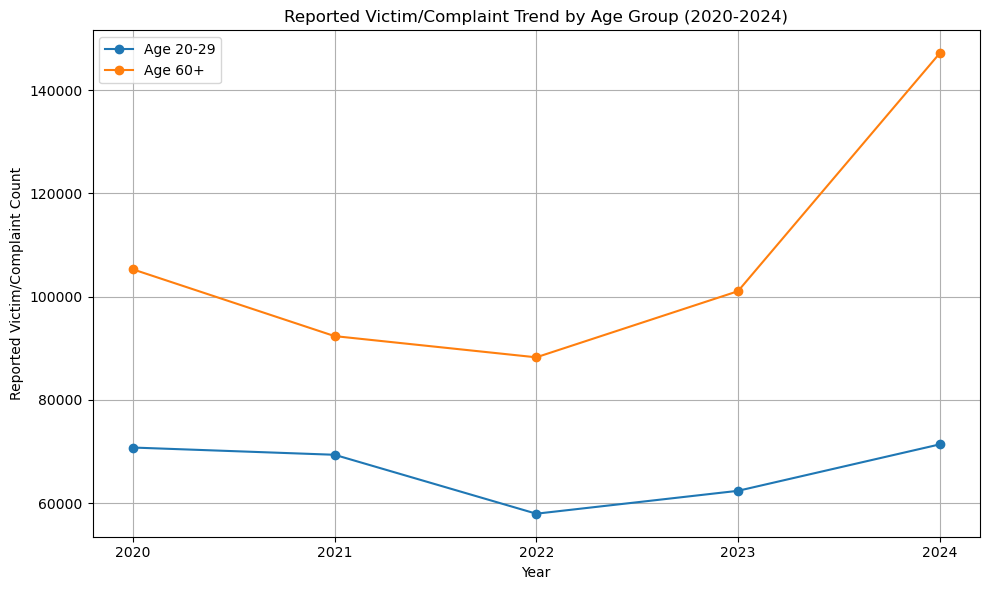

In [13]:
import matplotlib.pyplot as plt

age_20_29 = age_df[age_df["Age_Group"] == "20-29"]
age_60_plus = age_df[age_df["Age_Group"] == "60+"]

plt.figure(figsize=(10, 6))

plt.plot(
    age_20_29["Year"],
    age_20_29["Complaint_Count"],
    marker="o",
    label="Age 20-29"
)

plt.plot(
    age_60_plus["Year"],
    age_60_plus["Complaint_Count"],
    marker="o",
    label="Age 60+"
)

plt.title("Reported Victim/Complaint Trend by Age Group (2020-2024)")
plt.xlabel("Year")
plt.ylabel("Reported Victim/Complaint Count")
plt.xticks(age_df["Year"].unique())
plt.legend()
plt.grid(True)

plt.tight_layout()

# Chart ko PNG file ke roop mein save karna
plt.savefig("age_time_series.png", dpi=300, bbox_inches="tight")

plt.show()

In [15]:
state_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="02_State_Data"
)

state_df.head()

,Year,Source,State,Complaint_Count,Unit,Source_Report,Page/Table,Source_URL,Unnamed: 8,2024 Top 10 States by Scam Complaint Volume,Unnamed: 10
0,2024.0,FBI IC3,California,96265.0,Complaints,2024 IC3 Annual Report,Overall State Statistics - Complaints by State,NaN,NaN,State,2024 Complaints
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,California,96265
2,2024.0,FBI IC3,Texas,62347.0,Complaints,2024 IC3 Annual Report,Overall State Statistics - Complaints by State,NaN,NaN,Texas,62347
3,2024.0,FBI IC3,Florida,52191.0,Complaints,2024 IC3 Annual Report,Overall State Statistics - Complaints by State,NaN,NaN,Florida,52191
4,2024.0,FBI IC3,New York,36468.0,Complaints,2024 IC3 Annual Report,Overall State Statistics - Complaints by State,NaN,NaN,New York,36468


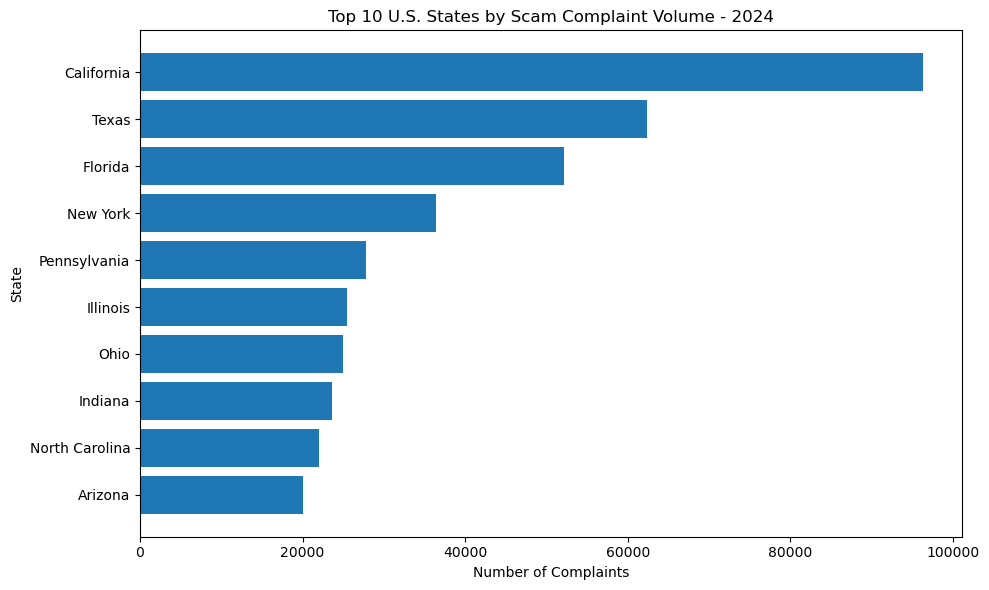

In [16]:
import matplotlib.pyplot as plt

top10_states = (
    state_df[state_df["Year"] == 2024]
    .sort_values("Complaint_Count", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_states["State"],
    top10_states["Complaint_Count"]
)

plt.title("Top 10 U.S. States by Scam Complaint Volume - 2024")
plt.xlabel("Number of Complaints")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("top10_states_2024.png", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
narrative_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="03_Scam_Narratives"
)

narrative_df.head()

,Narrative_ID,Scam_Type,Year,Platform,Scammer_Phrase,Urgency_Keyword,Phrase_or_Threat,Payment_Method,Specific_Demand,Victim_Action,Source,Source_URL
0,N001,Tech Support,2023,Phone / Pop-up,Your account has been hacked,now,Account or personal information is compromised,Gift Card / Cryptocurrency,Take immediate action and send payment,Contact fake support and make payment,FBI,https://www.fbi.gov/news/podcasts/inside-the-f...
1,N002,Government Impersonation,2022,Phone / Text,Urgent and aggressive demand,urgent,Threat of legal action or investigation,Prepaid Card / Wire Transfer / Cash / Cryptocu...,Make payment and do not tell anyone,Purchase payment method and provide payment de...,FBI IC3,https://www.ic3.gov/PSA/2022/PSA220307
2,N003,Cryptocurrency Exchange Impersonation,2024,Phone / Message,There is a problem with your account,immediately,Account may be compromised,Cryptocurrency,Provide login information or transfer cryptocu...,Click link or provide credentials and transfer...,FBI IC3,https://www.ic3.gov/PSA/2024/PSA240801
3,N004,Romance Fraud,2024,Dating Site / Social Media,I have an emergency and need money,emergency,Emotional pressure caused by a financial emerg...,Gift Card / Money Transfer / Cryptocurrency,Send money to solve the emergency,Send money or cryptocurrency,FTC,https://consumer.ftc.gov/consumer-alerts/2024/...
4,N005,Tech Support,2022,Email / Phone,Your subscription is about to renew,soon,Pressure to contact fake support about a suppo...,Wire Transfer / Prepaid Card / Cryptocurrency,Contact the provided support number and provid...,Contact scammer and provide banking information,FBI IC3,https://www.ic3.gov/PSA/2022/PSA221110


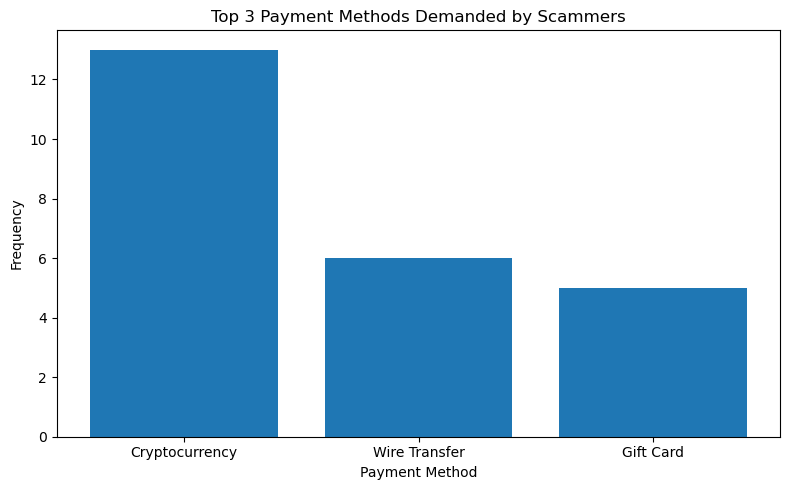

In [20]:
payment_counts = (
    narrative_df["Payment_Method"]
    .str.split(" / ")
    .explode()
    .str.strip()
    .value_counts()
    .head(3)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    payment_counts.index,
    payment_counts.values
)

plt.title("Top 3 Payment Methods Demanded by Scammers")
plt.xlabel("Payment Method")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("top3_payment_methods.png", dpi=300, bbox_inches="tight")

plt.show()

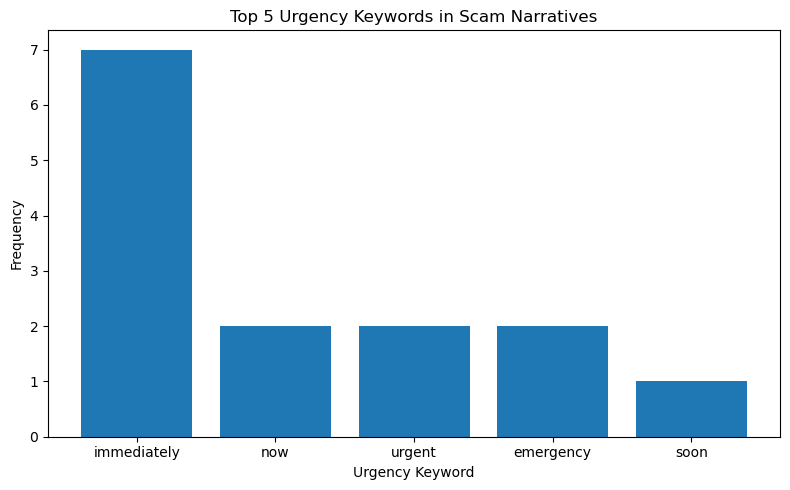

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Scam Narratives data
narrative_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="03_Scam_Narratives"
)

# Count top 5 urgency keywords
top5_urgency = (
    narrative_df["Urgency_Keyword"]
    .value_counts()
    .head(5)
)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    top5_urgency.index,
    top5_urgency.values
)

plt.title("Top 5 Urgency Keywords in Scam Narratives")
plt.xlabel("Urgency Keyword")
plt.ylabel("Frequency")

plt.tight_layout()

# Save chart
plt.savefig(
    "top5_urgency_keywords.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

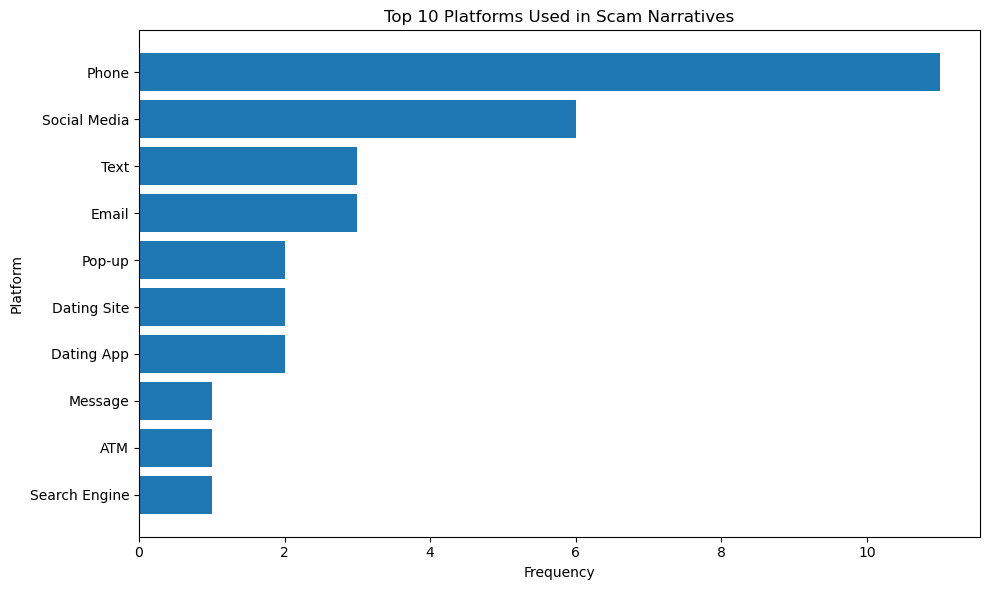

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Scam Narratives data
narrative_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="03_Scam_Narratives"
)

# Count individual platforms
platform_counts = (
    narrative_df["Platform"]
    .str.split(" / ")
    .explode()
    .str.strip()
    .value_counts()
)

# Select top 10 platforms
top_platforms = platform_counts.head(10)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_platforms.index[::-1],
    top_platforms.values[::-1]
)

plt.title("Top 10 Platforms Used in Scam Narratives")
plt.xlabel("Frequency")
plt.ylabel("Platform")

plt.tight_layout()

# Save chart
plt.savefig(
    "top10_platforms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

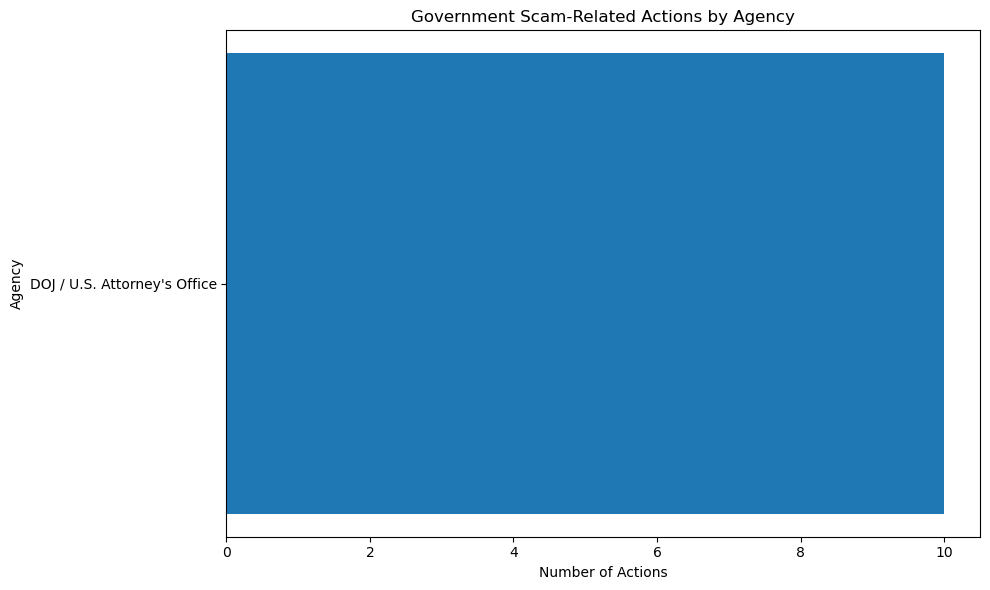

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Government Actions data from Excel
government_df = pd.read_excel(
    "Data_Matrix_P1.xlsx",
    sheet_name="04_Government_Actions"
)

# Count actions by agency
agency_counts = (
    government_df["Agency"]
    .value_counts()
)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    agency_counts.index[::-1],
    agency_counts.values[::-1]
)

plt.title("Government Scam-Related Actions by Agency")
plt.xlabel("Number of Actions")
plt.ylabel("Agency")

plt.tight_layout()

# Save chart
plt.savefig(
    "government_actions_by_agency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

### Key Business Insights

1. Older adults (60+) represent the highest-priority demographic in the analyzed data because their reported victim/complaint volume increased significantly compared with the 20–29 age group.

2. California had the highest scam complaint volume among the analyzed 2024 states, followed by Texas and Florida. This suggests that targeted awareness campaigns could be prioritized in high-volume states.

3. Scammers frequently use urgency and pressure tactics. The keyword "immediately" was the most frequently observed urgency keyword in the collected narratives.

4. Cryptocurrency was the most frequently observed payment method in the scam narratives, followed by wire transfers and gift cards.

5. Phone was the most frequently observed communication platform in the collected scam narratives.

6. Government enforcement and recovery actions demonstrate continued efforts to address scam-related financial losses. However, the available government-action dataset has limited agency coverage, which restricts broader comparison.

### Overall Business Implication

The analysis suggests that proactive scam prevention should focus on vulnerable demographics, high-risk communication channels, urgency-based scam detection, and risky payment methods. Real-time warnings and targeted interventions could help reduce victimization before financial losses occur.